# Тестирование обученного Cross-Encoder

Загружаем стабильную fine-tuned модель и проверяем её на вручную составленных парах (описание товара → пост в Telegram).

In [2]:
from sentence_transformers import CrossEncoder

STABLE_MODEL_PATH = "models/cross-encoder/stable/final"

model = CrossEncoder(STABLE_MODEL_PATH)
print(f"Модель загружена из: {STABLE_MODEL_PATH}")

The tokenizer you are loading from 'models/cross-encoder/stable/final' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Модель загружена из: models/cross-encoder/stable/final


## Тестовые пары

Каждая пара состоит из:
- **description** — описание товара (как у рекламодателя)
- **post** — текст поста из Telegram-канала
- **expected** — ожидаемая релевантность (0 = нерелевантно, 1 = очень релевантно)

Пары разбиты на три группы: **высокая**, **средняя** и **низкая** релевантность.

In [3]:
test_pairs = [
    # ── Высокая релевантность ──────────────────────────────────────────────────
    {
        "description": (
            "Беспроводные наушники с активным шумоподавлением ANC, временем работы до 30 часов, "
            "складной конструкцией и быстрой зарядкой. Поддерживают Bluetooth 5.3, "
            "идеальны для путешествий и работы в офисе."
        ),
        "post": (
            "Наконец-то нашёл идеальные наушники для перелётов! Взял себе беспроводные с шумодавом — "
            "и это просто небо и земля по сравнению с обычными вкладышами. В самолёте "
            "реально не слышишь гул двигателей. Заряда хватает на весь длинный рейс, "
            "а складываются компактно в чехол. Рекомендую всем, кто много летает!"
        ),
        "expected": 1.0,
        "group": "high",
    },
    {
        "description": (
            "Протеиновый батончик без сахара, 20 г белка в одной порции, "
            "вкус шоколадного брауни. Подходит для перекуса после тренировки, "
            "без глютена и ГМО, натуральный состав."
        ),
        "post": (
            "Попробовал новые протеиновые батончики без сахара — ожидал картон, "
            "а получил реально вкусный шоколадный снек. 20 граммов белка и при этом "
            "никакого послевкусия от сахарозаменителей. Закупился на месяц вперёд "
            "для перекусов после зала. Если ищете что-то чистое по составу — советую."
        ),
        "expected": 1.0,
        "group": "high",
    },
    {
        "description": (
            "Онлайн-курс по Python для начинающих: 60 уроков с нуля до первой работы. "
            "Живые вебинары, персональный ментор, разбор домашних заданий. "
            "Сертификат по окончании, помощь в трудоустройстве."
        ),
        "post": (
            "Друзья, дошёл до финала курса по питону — и это было реально полезно! "
            "Стартовал с полного нуля, а теперь написал свой первый телеграм-бот. "
            "Ментор отвечал на все вопросы, домашки разбирали по-настоящему. "
            "Уже обновил резюме и иду на первое собеседование. Очень рекомендую "
            "всем, кто хочет войти в айти без лишнего стресса."
        ),
        "expected": 1.0,
        "group": "high",
    },
    {
        "description": (
            "Умная колонка с голосовым ассистентом, поддерживает русский язык, "
            "управляет умным домом, встроенный стриминг музыки, 360° звук, "
            "компактный дизайн для любого интерьера."
        ),
        "post": (
            "Поставил умную колонку на кухне — теперь руки не нужны вообще. "
            "Говоришь вслух что включить, она включает. Попросил рецепт борща — "
            "зачитала по шагам. Свет в коридоре тоже через неё управляю. "
            "Звук для такого размера surprisingly хорош. Жена была скептиком, "
            "теперь пользуется чаще меня 😄"
        ),
        "expected": 0.9,
        "group": "high",
    },

    # ── Средняя релевантность ──────────────────────────────────────────────────
    {
        "description": (
            "Беспроводные наушники с активным шумоподавлением ANC, временем работы до 30 часов, "
            "складной конструкцией и быстрой зарядкой. Поддерживают Bluetooth 5.3."
        ),
        "post": (
            "Сегодня в подборке — лучшие гаджеты для продуктивной работы из дома. "
            "Эргономичное кресло, вертикальная мышь, второй монитор и, конечно, "
            "хорошие наушники чтобы не отвлекаться на шум. Какой у вас любимый "
            "гаджет для домашнего офиса?"
        ),
        "expected": 0.5,
        "group": "medium",
    },
    {
        "description": (
            "Протеиновый батончик без сахара, 20 г белка в одной порции, вкус шоколадного брауни."
        ),
        "post": (
            "Питание в период сушки — это боль. Пытаешься держать дефицит, а мозг "
            "требует сладкого. Спасаюсь перекусами с высоким белком, стараюсь "
            "минимизировать сахар. Кто как справляется с этим этапом?"
        ),
        "expected": 0.5,
        "group": "medium",
    },
    {
        "description": (
            "Онлайн-курс по Python для начинающих: 60 уроков с нуля до первой работы. "
            "Сертификат по окончании, помощь в трудоустройстве."
        ),
        "post": (
            "IT-рынок в 2025 году: нанимают ли джунов? Изучил вакансии на hh — "
            "python-разработчики по-прежнему в топе спроса даже без опыта, "
            "особенно если есть реальные проекты в портфолио. "
            "Главное — правильно подать себя на собеседовании."
        ),
        "expected": 0.5,
        "group": "medium",
    },

    # ── Низкая релевантность ──────────────────────────────────────────────────
    {
        "description": (
            "Беспроводные наушники с активным шумоподавлением ANC, временем работы до 30 часов."
        ),
        "post": (
            "Сегодня сварил новый рецепт супа — тыквенный с имбирём и кокосовым молоком. "
            "Получилось нежно и ароматно, семья в восторге. "
            "Рецепт скину в следующем посте!"
        ),
        "expected": 0.0,
        "group": "low",
    },
    {
        "description": (
            "Протеиновый батончик без сахара, 20 г белка, вкус шоколадного брауни."
        ),
        "post": (
            "Московский трафик сегодня — отдельный вид экстрима. Три часа в пробке "
            "на ТТК, и ощущение, что город просто встал. Когда же сделают "
            "нормальные развязки? 🚗🚗🚗"
        ),
        "expected": 0.0,
        "group": "low",
    },
    {
        "description": (
            "Онлайн-курс по Python для начинающих: 60 уроков с нуля, "
            "персональный ментор, сертификат, помощь в трудоустройстве."
        ),
        "post": (
            "Топ-5 кафе Санкт-Петербурга с видом на Неву — мои личные фавориты. "
            "Заходите, если бываете в городе, каждое из них стоит посетить. "
            "Особенно рекомендую третий пункт в списке — там невероятный закат."
        ),
        "expected": 0.0,
        "group": "low",
    },
    {
        "description": (
            "Умная колонка с голосовым ассистентом, управляет умным домом, "
            "встроенный стриминг музыки, 360° звук."
        ),
        "post": (
            "Прочитал новую книгу по поведенческой экономике — «Думай медленно, решай быстро». "
            "Если ещё не читали, очень советую: объясняет, почему мы принимаем "
            "иррациональные решения и как с этим работать."
        ),
        "expected": 0.0,
        "group": "low",
    },
]

print(f"Всего пар: {len(test_pairs)}")
print(f"  high   : {sum(1 for p in test_pairs if p['group'] == 'high')}")
print(f"  medium : {sum(1 for p in test_pairs if p['group'] == 'medium')}")
print(f"  low    : {sum(1 for p in test_pairs if p['group'] == 'low')}")

Всего пар: 11
  high   : 4
  medium : 3
  low    : 4


## Инференс

In [4]:
import numpy as np

pairs_input = [[p["description"], p["post"]] for p in test_pairs]

# Модель обучена с BinaryCrossEntropyLoss — CrossEncoder автоматически
# выставляет activation_fct=Sigmoid(), поэтому predict() уже возвращает [0, 1]
pred_scores = model.predict(pairs_input)

for p, pred in zip(test_pairs, pred_scores):
    p["pred"] = float(pred)

print("Инференс завершён.")

Инференс завершён.


## Результаты

In [5]:
import pandas as pd

rows = []
for i, p in enumerate(test_pairs):
    rows.append({
        "#": i + 1,
        "group": p["group"],
        "expected": p["expected"],
        "pred": round(p["pred"], 4),
        "description (50 chars)": p["description"][:50] + "…",
        "post (50 chars)": p["post"][:50] + "…",
    })

df = pd.DataFrame(rows)

GROUP_ORDER = {"high": 0, "medium": 1, "low": 2}
df = df.sort_values("group", key=lambda s: s.map(GROUP_ORDER)).reset_index(drop=True)

def color_pred(val):
    if val >= 0.65:
        return "background-color: #d4edda; color: #000000"
    elif val >= 0.35:
        return "background-color: #fff3cd; color: #000000"
    else:
        return "background-color: #f8d7da; color: #000000"

df.style.applymap(color_pred, subset=["pred"])

C:\Users\Admin\AppData\Local\Temp\ipykernel_15700\1927296475.py:27: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  df.style.applymap(color_pred, subset=["pred"])


,#,group,expected,pred,description (50 chars),post (50 chars)
0,1,high,1.000000,0.892000,Беспроводные наушники с активным шумоподавлением A…,Наконец-то нашёл идеальные наушники для перелётов!…
1,2,high,1.000000,0.935500,"Протеиновый батончик без сахара, 20 г белка в одно…",Попробовал новые протеиновые батончики без сахара …
2,3,high,1.000000,0.897000,Онлайн-курс по Python для начинающих: 60 уроков с …,"Друзья, дошёл до финала курса по питону — и это бы…"
3,4,high,0.900000,0.897400,"Умная колонка с голосовым ассистентом, поддерживае…",Поставил умную колонку на кухне — теперь руки не н…
4,5,medium,0.500000,0.481500,Беспроводные наушники с активным шумоподавлением A…,Сегодня в подборке — лучшие гаджеты для продуктивн…
5,6,medium,0.500000,0.004400,"Протеиновый батончик без сахара, 20 г белка в одно…",Питание в период сушки — это боль. Пытаешься держа…
6,7,medium,0.500000,0.502600,Онлайн-курс по Python для начинающих: 60 уроков с …,IT-рынок в 2025 году: нанимают ли джунов? Изучил в…
7,8,low,0.000000,0.045100,Беспроводные наушники с активным шумоподавлением A…,Сегодня сварил новый рецепт супа — тыквенный с имб…
8,9,low,0.000000,0.005900,"Протеиновый батончик без сахара, 20 г белка, вкус …",Московский трафик сегодня — отдельный вид экстрима…
9,10,low,0.000000,0.085600,Онлайн-курс по Python для начинающих: 60 уроков с …,Топ-5 кафе Санкт-Петербурга с видом на Неву — мои …


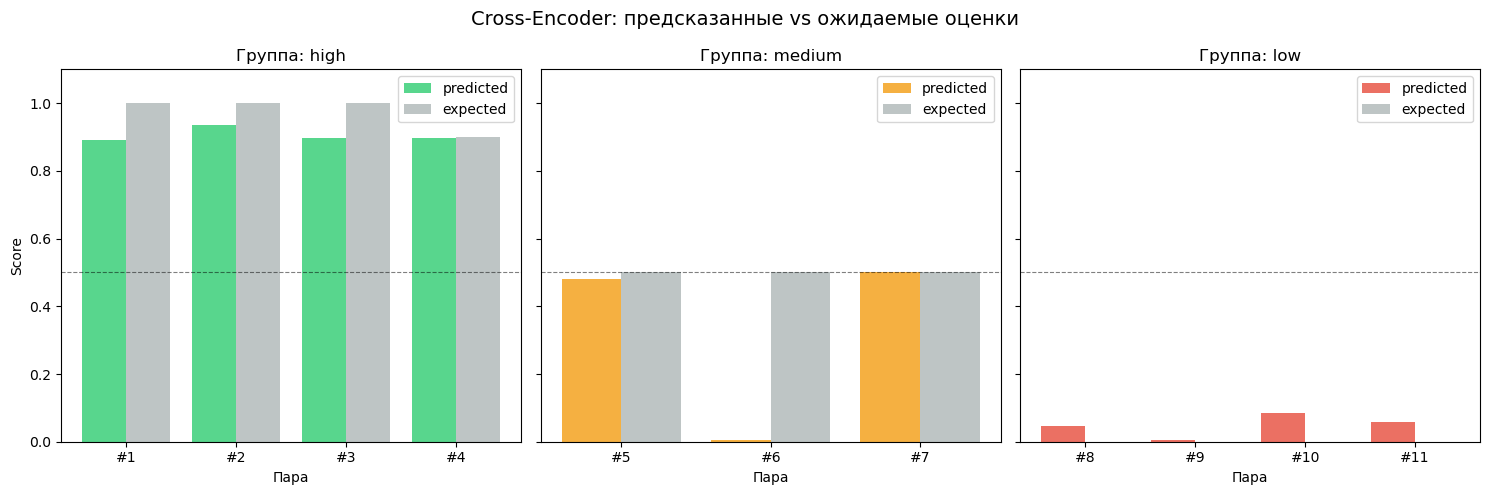

In [6]:
import matplotlib.pyplot as plt

GROUP_COLORS = {"high": "#2ecc71", "medium": "#f39c12", "low": "#e74c3c"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, group in zip(axes, ["high", "medium", "low"]):
    group_pairs = [p for p in test_pairs if p["group"] == group]
    indices     = [f"#{i+1}" for i, p in enumerate(test_pairs) if p["group"] == group]
    preds       = [p["pred"] for p in group_pairs]
    expected    = [p["expected"] for p in group_pairs]

    x = range(len(group_pairs))
    ax.bar(x, preds,    width=0.4, label="predicted", color=GROUP_COLORS[group], alpha=0.8, align="center")
    ax.bar([i + 0.4 for i in x], expected, width=0.4, label="expected",  color="#7f8c8d", alpha=0.5, align="center")

    ax.set_xticks([i + 0.2 for i in x])
    ax.set_xticklabels(indices)
    ax.set_ylim(0, 1.1)
    ax.set_title(f"Группа: {group}")
    ax.set_xlabel("Пара")
    ax.legend()
    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

axes[0].set_ylabel("Score")
fig.suptitle("Cross-Encoder: предсказанные vs ожидаемые оценки", fontsize=14)
plt.tight_layout()
plt.show()

## Метрики качества

In [7]:
from scipy.stats import spearmanr, pearsonr

all_pred     = [p["pred"]     for p in test_pairs]
all_expected = [p["expected"] for p in test_pairs]

spearman_corr, spearman_p = spearmanr(all_pred, all_expected)
pearson_corr,  pearson_p  = pearsonr(all_pred,  all_expected)

# Accuracy: порог 0.5 → бинарная классификация (релевантно / нет)
binary_pred = [1 if s >= 0.5 else 0 for s in all_pred]
binary_true = [1 if s >= 0.5 else 0 for s in all_expected]
accuracy    = sum(p == t for p, t in zip(binary_pred, binary_true)) / len(binary_pred)

mae = np.mean(np.abs(np.array(all_pred) - np.array(all_expected)))

print("=" * 50)
print("МЕТРИКИ НА ТЕСТОВЫХ ПАРАХ")
print("=" * 50)
print(f"Spearman r  : {spearman_corr:+.4f}  (p={spearman_p:.4f})")
print(f"Pearson r   : {pearson_corr:+.4f}  (p={pearson_p:.4f})")
print(f"MAE         : {mae:.4f}")
print(f"Accuracy@0.5: {accuracy:.2%}  ({sum(p == t for p, t in zip(binary_pred, binary_true))}/{len(binary_pred)})")
print()
print("Разбивка по группам:")
for group in ["high", "medium", "low"]:
    gp = [p for p in test_pairs if p["group"] == group]
    g_preds = [p["pred"] for p in gp]
    g_exp   = [p["expected"] for p in gp]
    g_mae   = np.mean(np.abs(np.array(g_preds) - np.array(g_exp)))
    print(f"  {group:8s}: avg_pred={np.mean(g_preds):.4f}  expected_avg={np.mean(g_exp):.4f}  MAE={g_mae:.4f}")

МЕТРИКИ НА ТЕСТОВЫХ ПАРАХ
Spearman r  : +0.7874  (p=0.0040)
Pearson r   : +0.9314  (p=0.0000)
MAE         : 0.0900
Accuracy@0.5: 81.82%  (9/11)

Разбивка по группам:
  high    : avg_pred=0.9055  expected_avg=0.9750  MAE=0.0695
  medium  : avg_pred=0.3295  expected_avg=0.5000  MAE=0.1722
  low     : avg_pred=0.0487  expected_avg=0.0000  MAE=0.0487


---
## Интерактивное тестирование одной пары

Меняйте `description` и `post` в следующей ячейке и запускайте две ячейки ниже.

In [8]:
def predict_single(description: str, post: str) -> float:
    """Возвращает score модели для одной пары."""
    return float(model.predict([[description, post]]))


def show_gauge(score: float, description: str, post: str) -> None:
    """Горизонтальный gauge-бар с цветовым градиентом и текстами пары."""
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    fig, axes = plt.subplots(
        3, 1,
        figsize=(10, 4),
        gridspec_kw={"height_ratios": [1, 0.35, 0.35]},
    )

    # ── gauge ──────────────────────────────────────────────
    ax = axes[0]
    gradient = np.linspace(0, 1, 300).reshape(1, -1)
    ax.imshow(gradient, aspect="auto", cmap="RdYlGn", extent=[0, 1, 0, 1])

    ax.axvline(score, color="black", linewidth=3)
    ax.plot(score, 0.5, "v", color="black", markersize=14)
    ax.text(
        score, 1.18, f"{score:.4f}",
        ha="center", va="bottom", fontsize=14, fontweight="bold",
        transform=ax.transData,
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(["0", "0.25", "0.5", "0.75", "1.0"], fontsize=10)
    ax.set_title("Score модели", fontsize=12, pad=20)
    ax.axvline(0.5, color="white", linewidth=1, linestyle="--", alpha=0.7)

    # ── description ────────────────────────────────────────
    for sub_ax, label, text in zip(
        axes[1:],
        ["Описание товара", "Текст поста"],
        [description, post],
    ):
        sub_ax.axis("off")
        wrapped = text if len(text) <= 120 else text[:117] + "…"
        sub_ax.text(
            0, 0.7, f"{label}:",
            fontsize=9, fontweight="bold", va="top", transform=sub_ax.transAxes,
        )
        sub_ax.text(
            0, 0.1, wrapped,
            fontsize=9, va="top", wrap=True, transform=sub_ax.transAxes,
        )

    plt.tight_layout()
    plt.show()


def show_single_result(description: str, post: str) -> None:
    """Предсказывает score и выводит gauge + текстовый вывод."""
    score = predict_single(description, post)

    if score >= 0.65:
        verdict, color = "ВЫСОКАЯ", "\033[32m"
    elif score >= 0.35:
        verdict, color = "СРЕДНЯЯ", "\033[33m"
    else:
        verdict, color = "НИЗКАЯ", "\033[31m"

    print(f"Score : {color}{score:.2f}\033[0m")
    print(f"Релевантность: {color}{verdict}\033[0m")

    show_gauge(score, description, post)


print("Вспомогательные функции определены.")

Вспомогательные функции определены.


C:\Users\Admin\AppData\Local\Temp\ipykernel_15700\1411317245.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float(model.predict([[description, post]]))


Fine-tuned (stable) : 0.30  НИЗКАЯ
Базовая модель      : 0.25  НИЗКАЯ


C:\Users\Admin\AppData\Local\Temp\ipykernel_15700\2160691941.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score_base = float(base_model.predict([[description, post]]))


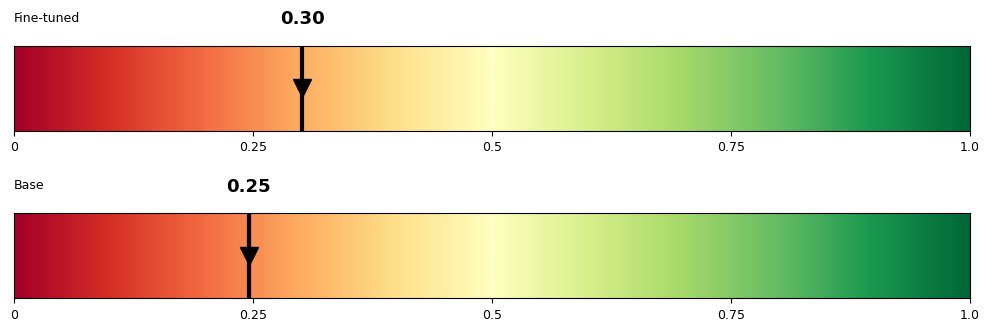

In [12]:
# ── Подставляйте сюда свои тексты ────────────────────────────────────────────

description = """
34-дюймовый дисплей octopus с разрешением 4K 165 Гц отличается увеличенным размером, высоким разрешением и высокой частотой обновления.

1.Сверхширокий экран: Соотношение сторон экрана составляет 21:9, что больше, чем у традиционного дисплея 16:9, что обеспечивает более широкое поле зрения и улучшает качество игр, просмотра фильмов, многозадачности и т.д.

2.Высокое разрешение: разрешение 4K (3440×1440) позволяет получать четкие изображения с высокой детализацией.

3.Высокая частота обновления: Частота обновления 165 Гц позволяет сделать изображение более плавным и уменьшить остаточное изображение и размытие, особенно для киберспортсменов и высококлассных геймеров, она позволяет более точно отображать изображение на экране, тем самым уменьшая задержку и разрывы, а также улучшая качество игры.

4.Сильное ощущение погружения: широкий экран и возможный дизайн изогнутой поверхности (кривизна 1500R) создают у пользователей определенное ощущение обертывания и погружения в визуальный мир.

5.Хорошая цветопередача: он обычно имеет широкий охват цветовой гаммы, цветовое отображение является естественным и насыщенным, и он может лучше отображать различные цвета.Он достигает 121% цветовой гаммы sRGB и 102% цветовой гаммы DCI-P3.

6.Богатые интерфейсы: оснащенный несколькими интерфейсами, такими как HDMI 2.0 и DP 1.2, он удобен для подключения различных устройств, включая порты аудиовыхода, USB и т.д.

7.Многофункциональность: поддерживает технологию AMD FreeSync для уменьшения разрывов экрана; имеет подъемный и вращающийся кронштейн, с помощью которого можно гибко регулировать высоту и угол наклона дисплея; также имеет функцию PIP / PBP, которая позволяет подключать два компьютера одновременно и отображать несколько экранов.""".strip()

post = """
Лучшие компоненты для зоны вокруг глаз, которые действительно работают.

Кожа вокруг глаз является самой тонкой и нежной и именно здесь первыми проявляются признаки усталости и старения. Однако, с правильными ингредиентами вы можете поддерживать упругость, сияние и гладкость этой области.

Давайте рассмотрим ключевые компоненты, которые действительно эффективны:

🟢Пептиды - стимулируют производство коллагена, улучшают упругость кожи и уменьшают морщины. Особенно полезны медные пептиды и Matrixyl.

🟢Кофеин - помогает уменьшить отеки, улучшает циркуляцию крови, и уменьшает появление темных кругов под глазами.

🟢Гиалуроновая кислота - интенсивно увлажняет кожу, делая ее более плотной и гладкой. Особенно важна при сухости кожи, но важно контролировать дозировку, чтобы избежать отечности.

🟢Ниацинамид (витамин B3) - осветляет пигментацию, укрепляет защитный барьер кожи, уменьшает темные круги под глазами и придает коже свежий вид.

🟢Экстракт зеленого чая или огурца - натуральные антиоксиданты, которые снимают раздражение, успокаивают кожу и борются с повреждениями от свободных радикалов.

🟢Ретинол в микродозах - ускоряет обновление клеток и борется с морщинами. Однако важно выбирать формулы, специально разработанные для области вокруг глаз, мягкие и безопасные. В своих кремах я использую - бакучиол.

⚠️ Совет: При нанесении ухода вокруг глаз не тяните кожу - используйте легкие похлопывающие движения с подушечками пальцев.""".strip()

# ─────────────────────────────────────────────────────────────────────────────

BASE_MODEL_NAME = "DiTy/cross-encoder-russian-msmarco"

if "base_model" not in dir():
    from sentence_transformers import CrossEncoder as _CE
    base_model = _CE(BASE_MODEL_NAME)
    print(f"Базовая модель загружена: {BASE_MODEL_NAME}")

score_ft   = predict_single(description, post)
score_base = float(base_model.predict([[description, post]]))

# ── текстовый вывод ──────────────────────────────────────────────────────────
def _verdict(s):
    if s >= 0.65: return "ВЫСОКАЯ",  "\033[32m"
    if s >= 0.35: return "СРЕДНЯЯ",  "\033[33m"
    return              "НИЗКАЯ",   "\033[31m"

v_ft,   c_ft   = _verdict(score_ft)
v_base, c_base = _verdict(score_base)

print(f"Fine-tuned (stable) : {c_ft}{score_ft:.2f}  {v_ft}\033[0m")
print(f"Базовая модель      : {c_base}{score_base:.2f}  {v_base}\033[0m")

# ── два gauge рядом ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

gradient = np.linspace(0, 1, 300).reshape(1, -1)

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 3.5),
)

for ax, score, label in zip(
    axes,
    [score_ft, score_base],
    ["Fine-tuned", f"Base"],
):
    ax.imshow(gradient, aspect="auto", cmap="RdYlGn", extent=[0, 1, 0, 1])
    ax.axvline(score, color="black", linewidth=3)
    ax.plot(score, 0.5, "v", color="black", markersize=13)
    ax.text(score, 1.22, f"{score:.2f}",
            ha="center", va="bottom", fontsize=13, fontweight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticklabels(["0", "0.25", "0.5", "0.75", "1.0"], fontsize=9)
    ax.set_title(label, fontsize=9, pad=18, loc="left")
    ax.axvline(0.5, color="white", linewidth=1, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()